In [71]:
import pandas as pd
import  matplotlib.pyplot as plt

# Task1.1: Load and inspect data

In [2]:
data = pd.read_csv("Railway_info.csv")

In [3]:
data.head(10)

,Train_No,Train_Name,Source_Station_Name,Destination_Station_Name,days
0,107,SWV-MAO-VLNK,SAWANTWADI ROAD,MADGOAN JN.,Saturday
1,108,VLNK-MAO-SWV,MADGOAN JN.,SAWANTWADI ROAD,Friday
2,128,MAO-KOP SPEC,MADGOAN JN.,CHHATRAPATI SHAHU MAHARAJ TERMINUS,Friday
3,290,PALACE ON WH,DELHI-SAFDAR JANG,DELHI-SAFDAR JANG,Wednesday
4,401,BSB BHARATDA,AURANGABAD,VARANASI JN.,Saturday
5,421,LKO-SVDK FTR,LUCKNOW JN.,SHRI MATA VAISHNO DEVI KATRA,Tuesday
6,422,SVDK-LKO FTR,SHRI MATA VAISHNO DEVI KATRA,LUCKNOW JN.,Monday
7,477,FTR TRAIN NO,SIRSA,SIRSA,Sunday
8,502,RJPB-UMB FTR,RAJENDRANAGAR TERMINAL,AMBALA CANTT JN,Monday
9,504,PNBE-BTI FTR,PATNA JN.,BATHINDA JN,Wednesday


In [4]:
data.info()
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11113 entries, 0 to 11112
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Train_No                  11113 non-null  int64 
 1   Train_Name                11113 non-null  object
 2   Source_Station_Name       11113 non-null  object
 3   Destination_Station_Name  11113 non-null  object
 4   days                      11113 non-null  object
dtypes: int64(1), object(4)
memory usage: 434.2+ KB
Train_No                    0
Train_Name                  0
Source_Station_Name         0
Destination_Station_Name    0
days                        0
dtype: int64


# Task 1.2: Basic Statistics

In [5]:
print("Total no of trains:",data["Train_No"].count())
print("unique source stations",data["Source_Station_Name"].nunique())
print("unique destination stations" , data["Destination_Station_Name"].nunique())

Total no of trains: 11113
unique source stations 921
unique destination stations 924


In [6]:
#most common source and destinations
print(data["Source_Station_Name"].value_counts().head(1))
print(data["Destination_Station_Name"].value_counts().head(1))

Source_Station_Name
CST-MUMBAI    513
Name: count, dtype: int64
Destination_Station_Name
CST-MUMBAI    514
Name: count, dtype: int64



# Task 1.3: Data Cleaning


In [7]:
data["Source_Station_Name"] = data["Source_Station_Name"].str.upper()
data["Destination_Station_Name"] = data["Destination_Station_Name"].str.upper()

data.fillna("UNKNOWN", inplace=True)

In [8]:
data.head()

,Train_No,Train_Name,Source_Station_Name,Destination_Station_Name,days
0,107,SWV-MAO-VLNK,SAWANTWADI ROAD,MADGOAN JN.,Saturday
1,108,VLNK-MAO-SWV,MADGOAN JN.,SAWANTWADI ROAD,Friday
2,128,MAO-KOP SPEC,MADGOAN JN.,CHHATRAPATI SHAHU MAHARAJ TERMINUS,Friday
3,290,PALACE ON WH,DELHI-SAFDAR JANG,DELHI-SAFDAR JANG,Wednesday
4,401,BSB BHARATDA,AURANGABAD,VARANASI JN.,Saturday


In [9]:
print(data.isnull().sum())

Train_No                    0
Train_Name                  0
Source_Station_Name         0
Destination_Station_Name    0
days                        0
dtype: int64


In [53]:
print(data["Train_Name"].value_counts())
data["Train_Name"].count()

Train_Name
TBM-MSB EMU     139
MSB-TBM EMU     137
PASS             74
VLCY-MSBEMUL     70
CGL-MSB EMU      65
               ... 
MYS - HWH SF      1
HWH-MYS SF E      1
ERS - BSP SF      1
BSP - ERS SF      1
RE-MTC PASSE      1
Name: count, Length: 7580, dtype: int64


np.int64(11113)

### so Total no of train are 11,113

# level -2

## Task 2.1: Data Filtering

In [24]:
sat_trains = data[data["days"] == "Saturday"]
print(sat_trains.head())

    Train_No    Train_Name Source_Station_Name Destination_Station_Name  \
0        107  SWV-MAO-VLNK     SAWANTWADI ROAD              MADGOAN JN.   
4        401  BSB BHARATDA          AURANGABAD             VARANASI JN.   
21      1196  NGP-KRMI SPL      NAGPUR JN.(CR)                  KARMALI   
28      1706   JBP-BDTS SF            JABALPUR          BANDRA TERMINUS   
45      2834  SRC-RJT SF A     SANTRAGACHI JN.                   RAJKOT   

        days  
0   Saturday  
4   Saturday  
21  Saturday  
28  Saturday  
45  Saturday  


In [30]:
data["days"].value_counts()

days
Friday        1471
Tuesday       1454
Wednesday     1448
Saturday      1441
Sunday        1432
Thursday      1372
Monday        1342
Fridayd        178
Tuesdayd       174
Sundayd        170
Wednesdayd     164
Mondayd        161
Thursdayd      154
Saturdayd      152
Name: count, dtype: int64

In [33]:
aur_trains = data[data["Source_Station_Name"] == "AURANGABAD"]
aur_trains

,Train_No,Train_Name,Source_Station_Name,Destination_Station_Name,days
4,401,BSB BHARATDA,AURANGABAD,VARANASI JN.,Saturday
204,7505,AWB-QLN,AURANGABAD,QUILON,Wednesday
2268,17619,AWB-NED WEEK,AURANGABAD,NANDED,Sunday
2270,17621,AWB-RU EXP,AURANGABAD,RENIGUNTA JN.,Saturday
7303,57550,AWB-HYB PASS,AURANGABAD,HYDERABAD DECCAN,Sunday


 # Task 2.2: Grouping and Aggregation

In [37]:
data["Source_Station_Name"].value_counts()

Source_Station_Name
CST-MUMBAI         513
SEALDAH            372
CHENNAI BEACH      339
HOWRAH JN.         338
KALYAN JN          285
                  ... 
MANENDRAGARH         1
LANJI GARH ROAD      1
FURKATING JN.        1
TALCHER              1
KOLAGHAT             1
Name: count, Length: 921, dtype: int64

In [47]:
daily_count = data.groupby(
    ["Source_Station_Name", "days"]
).size().reset_index(name="Train_Count")

print(daily_count.head())

  Source_Station_Name       days  Train_Count
0        ABHANPUR JN.   Saturday            1
1        ABHANPUR JN.    Tuesday            1
2              ABOHAR  Wednesday            1
3            ABU ROAD    Tuesday            1
4        ACHHNERA JN.   Saturday            1


In [49]:
avg_trains = daily_count.groupby("Source_Station_Name")["Train_Count"].mean()

print(avg_trains)

Source_Station_Name
ABHANPUR JN.      1.000000
ABOHAR            1.000000
ABU ROAD          1.000000
ACHHNERA JN.      1.000000
ADILABAD          1.250000
                    ...   
WARASEONI         1.000000
WARDHA JN.        1.000000
WHITE FIELD       1.000000
YAMUNA BRIDGE     1.000000
YESVANTPUR JN.    8.571429
Name: Train_Count, Length: 921, dtype: float64


# Task 2.3: Data Enrichment

In [68]:
def categorize(day):
    if day in ["Saturday", "Sunday"]:
        return "Weekend"
    else:
        return "Weekday"

data["Category"] = data["days"].apply(categorize)
d1 = pd.DataFrame(data)
d1

,Train_No,Train_Name,Source_Station_Name,Destination_Station_Name,days,Category
0,107,SWV-MAO-VLNK,SAWANTWADI ROAD,MADGOAN JN.,Saturday,Weekend
1,108,VLNK-MAO-SWV,MADGOAN JN.,SAWANTWADI ROAD,Friday,Weekday
2,128,MAO-KOP SPEC,MADGOAN JN.,CHHATRAPATI SHAHU MAHARAJ TERMINUS,Friday,Weekday
3,290,PALACE ON WH,DELHI-SAFDAR JANG,DELHI-SAFDAR JANG,Wednesday,Weekday
4,401,BSB BHARATDA,AURANGABAD,VARANASI JN.,Saturday,Weekend
...,...,...,...,...,...,...
11108,99904,PUNE-TGN EMU,PUNE JN.,TALEGAON,Tuesday,Weekday
11109,99905,EMU,TALEGAON,SHIVAJINAGAR,Monday,Weekday
11110,99906,EMU,PUNE JN.,TALEGAON,Wednesday,Weekday
11111,99907,EMU,TALEGAON,PUNE JN.,Thursday,Weekday


# Level 3: Advanced Data Analysis


## Task 3.1: Pattern Analysis

In [77]:
day_counts = data["days"].value_counts()

print(day_counts)

days
Friday        1471
Tuesday       1454
Wednesday     1448
Saturday      1441
Sunday        1432
Thursday      1372
Monday        1342
Fridayd        178
Tuesdayd       174
Sundayd        170
Wednesdayd     164
Mondayd        161
Thursdayd      154
Saturdayd      152
Name: count, dtype: int64


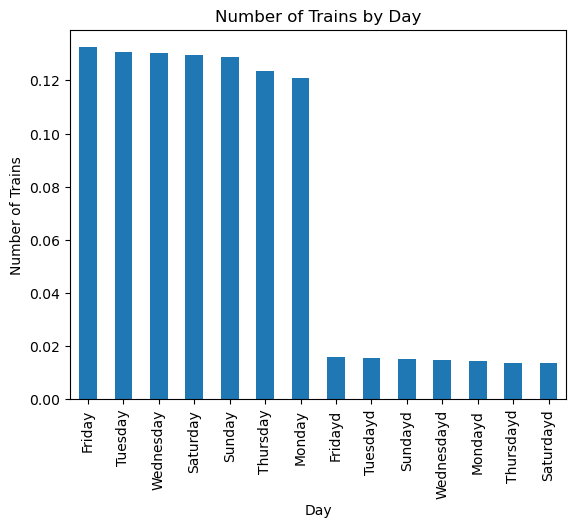

In [76]:
day_counts.plot(kind="bar")

plt.title("Number of Trains by Day")
plt.xlabel("Day")
plt.ylabel("Number of Trains")

plt.show()